In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# CONFIG
# ============================================================
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"
SECTOR_COL = "sector"        # change if your sector column name differs
YEAR_COL = "Year"            # only used for yearly time-based splits, if present
EXCLUDE_FEATURES = ["avg_range_pct", "volatility"]   # from PCA decision
MIN_SAMPLES_PER_SECTOR = 30  # skip tiny sectors

# ============================================================
# Helper: signed log transform
# ============================================================
def signed_log1p(x):
    """Applies sign(x) * log1p(|x|) elementwise."""
    return np.sign(x) * np.log1p(np.abs(x))

# ============================================================
# Collect results across all datasets / sectors / models
# ============================================================
all_rows = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # sanity checks
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue
    if SECTOR_COL not in df.columns:
        print(f"  [SKIP] sector column '{SECTOR_COL}' not found in {file}")
        continue

    # make sure target is numeric
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL, SECTOR_COL])

    # numeric feature columns
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)

    # drop excluded features
    num_cols = [c for c in num_cols if c not in EXCLUDE_FEATURES]

    if not num_cols:
        print("  [SKIP] no usable numeric features after exclusions.")
        continue

    print(f"  Using features: {num_cols}")

    # flag if we have a Year column for time-based split (usually yearly files)
    has_year = YEAR_COL in df.columns

    # models to compare
    model_defs = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
    }

    # --------------------------------------------------------
    # PER-SECTOR LOOP
    # --------------------------------------------------------
    for sector_name, sector_df in df.groupby(SECTOR_COL):
        if len(sector_df) < MIN_SAMPLES_PER_SECTOR:
            continue

        # Build data table for this sector
        sector_data = sector_df.copy()

        # if yearly and Year exists, sort chronologically & split by time
        if has_year:
            sector_data = sector_data.dropna(subset=num_cols + [TARGET_COL, YEAR_COL])
            sector_data = sector_data.sort_values(YEAR_COL)
        else:
            sector_data = sector_data.dropna(subset=num_cols + [TARGET_COL])

        if len(sector_data) < MIN_SAMPLES_PER_SECTOR:
            continue

        X_raw = sector_data[num_cols]
        y = sector_data[TARGET_COL]
        n_samples = len(sector_data)

        if has_year:
            # chronological 80/20 split
            n = len(sector_data)
            split_idx = int(0.8 * n)
            train = sector_data.iloc[:split_idx]
            test = sector_data.iloc[split_idx:]

            X_train_raw = train[num_cols]
            y_train = train[TARGET_COL]
            X_test_raw = test[num_cols]
            y_test = test[TARGET_COL]
        else:
            # random 80/20 split for monthly datasets without Year
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y, test_size=0.2, random_state=42
            )

        # clip target outliers based on train only
        q_low = y_train.quantile(0.01)
        q_high = y_train.quantile(0.99)
        y_train_clipped = y_train.clip(lower=q_low, upper=q_high)
        y_test_clipped = y_test.clip(lower=q_low, upper=q_high)

        # transform & scale features
        X_train_log = signed_log1p(X_train_raw)
        X_test_log = signed_log1p(X_test_raw)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_log)
        X_test = scaler.transform(X_test_log)

        # fit/evaluate all models
        for model_name, model in model_defs.items():
            model.fit(X_train, y_train_clipped)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test_clipped, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
            r2 = r2_score(y_test_clipped, y_pred)

            all_rows.append({
                "Dataset": file,
                "Sector": sector_name,
                "Model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
                "n_samples": n_samples,
            })

# ============================================================
# Aggregate & pick best (dataset, model) by mean R²
# ============================================================
results_df = pd.DataFrame(all_rows)
if results_df.empty:
    raise RuntimeError("No results collected – check file paths / column names.")

# mean R² per (Dataset, Model)
summary = (
    results_df
    .groupby(["Dataset", "Model"], as_index=False)["R2"]
    .mean()
    .rename(columns={"R2": "mean_R2"})
)

print("\n=== Mean R² by Dataset and Model ===")
print(summary.sort_values("mean_R2", ascending=False).to_string(index=False))

best_row = summary.loc[summary["mean_R2"].idxmax()]
best_dataset = best_row["Dataset"]
best_model = best_row["Model"]

print(f"\nBest overall regression configuration by mean R²:")
print(f"  Dataset: {best_dataset}")
print(f"  Model:   {best_model}")
print(f"  mean R²: {best_row['mean_R2']:.3f}")

# ============================================================
# Extract 9 sectors for the best dataset+model and build table
# ============================================================
best_results = results_df[
    (results_df["Dataset"] == best_dataset) &
    (results_df["Model"] == best_model)
].copy()

# pick 9 sectors with most samples (you can change this to top-9 R² if preferred)
best_results = best_results.sort_values("n_samples", ascending=False)
top9 = best_results.head(9).copy()

# sort nicely by sector name and round metrics
top9 = top9.sort_values("Sector")
top9_display = top9[["Sector", "MAE", "RMSE", "R2"]].copy()
top9_display[["MAE", "RMSE", "R2"]] = top9_display[["MAE", "RMSE", "R2"]].round(3)

print(f"\n=== Regression Performance for {best_model} on {best_dataset} (Top 9 Sectors) ===")
print(top9_display.to_string(index=False))

# optional: save as CSV to paste into the paper
top9_display.to_csv("regression_best_dataset_top9_sectors.csv", index=False)



=== Processing file: sp500_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: sp500_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nasdaq_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nasdaq_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nyse_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nyse_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: forbes2000_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: forbes2000_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Mean R² by Dataset and Model ===
               Dataset             Model       mean_R2
     

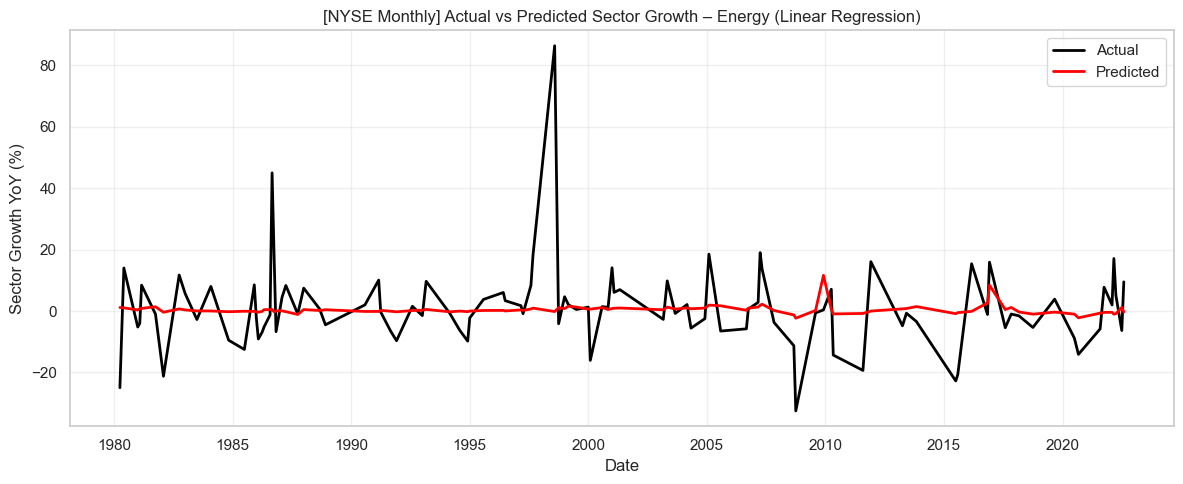

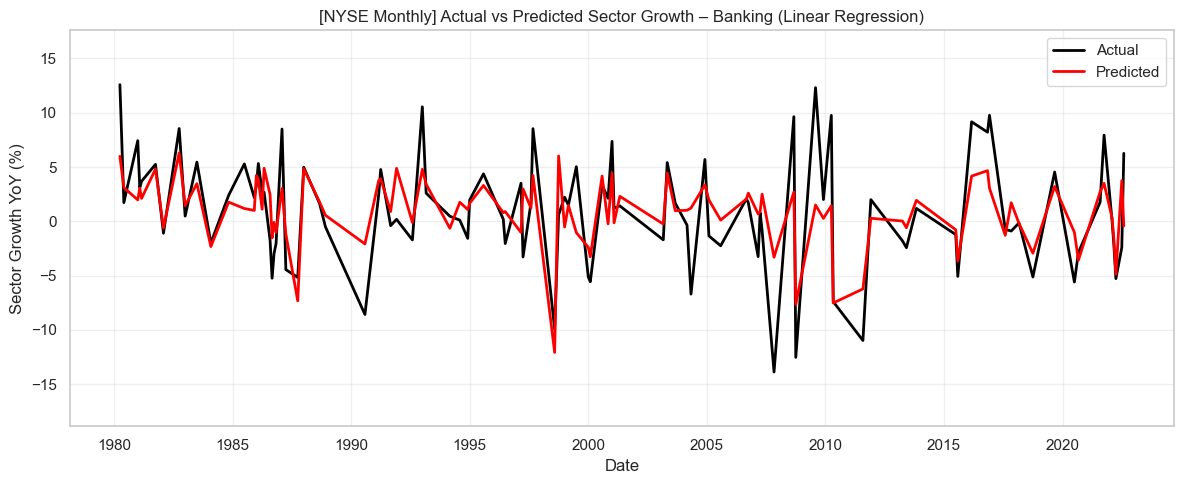

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =====================================================
# CONFIG – use your best model + dataset here
# =====================================================
CSV_FILE = "nyse_monthly.csv"
TARGET_COL = "sector_growth_yoy"
SECTOR_COL = "sector"
DATE_COL = "YearMonth"  # or change to 'Date' or 'Year' depending on file
EXCLUDE_FEATURES = ["avg_range_pct", "volatility"]
SELECTED_SECTORS = ["Energy", "Banking"]  # Change sectors here

# =====================================================
# Load and clean dataset
# =====================================================
df = pd.read_csv(CSV_FILE)

# Drop rows with missing target or sector
df = df.dropna(subset=[TARGET_COL, SECTOR_COL])

# Extract datetime
if "YearMonth" in df.columns:
    df["Date"] = pd.to_datetime(df["YearMonth"])
elif "Year" in df.columns:
    df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-01-01")
else:
    raise ValueError("No valid date column found in dataset.")

# Keep only numeric features (excluding target)
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
for col in [TARGET_COL] + EXCLUDE_FEATURES:
    if col in num_cols:
        num_cols.remove(col)

# =====================================================
# Build regression_df with predictions per sector
# =====================================================
all_rows = []

for sector_name, group in df.groupby(SECTOR_COL):
    if sector_name not in SELECTED_SECTORS:
        continue

    group = group.sort_values("Date")
    X_raw = group[num_cols]
    y = group[TARGET_COL]
    dates = group["Date"]

    # Skip sectors with too little data
    if len(group) < 10:
        continue

    # Train/test split
    X_train_raw, X_test_raw, y_train, y_test, dates_train, dates_test = train_test_split(
        X_raw, y, dates, test_size=0.2, random_state=42
    )

    # Transform features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Store results
    for d, yt, yp in zip(dates_test, y_test, y_pred):
        all_rows.append({
            "Date": d,
            "Sector": sector_name,
            "Actual": yt,
            "Predicted": yp
        })

# Create DataFrame
regression_df = pd.DataFrame(all_rows)

# =====================================================
# Plotting function – Actual vs Predicted
# =====================================================
def plot_regression_sector(regression_df, sector_name, dataset_name="NYSE Monthly", model_name="Linear Regression", save=False):
    df = regression_df[regression_df["Sector"] == sector_name].copy()
    if df.empty:
        print(f"[WARNING] No data found for sector: {sector_name}")
        return

    df = df.sort_values("Date")
    actual = df["Actual"].values
    predicted = df["Predicted"].values
    dates = df["Date"].values

    plt.figure(figsize=(12, 5))
    plt.plot(dates, actual, label="Actual", color="black", linewidth=2)
    plt.plot(dates, predicted, label="Predicted", color="red", linewidth=2)

    plt.title(f"[{dataset_name}] Actual vs Predicted Sector Growth – {sector_name} ({model_name})")
    plt.xlabel("Date")
    plt.ylabel("Sector Growth YoY (%)")
    plt.ylim(min(actual.min(), predicted.min()) - 5, max(actual.max(), predicted.max()) + 5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        filename = f"{sector_name.lower().replace(' ', '_')}_regression_plot.png"
        plt.savefig(filename, dpi=300)
        print(f"Saved plot as: {filename}")
    else:
        plt.show()

# =====================================================
# Plot selected sectors
# =====================================================
for sector in SELECTED_SECTORS:
    plot_regression_sector(regression_df, sector)
